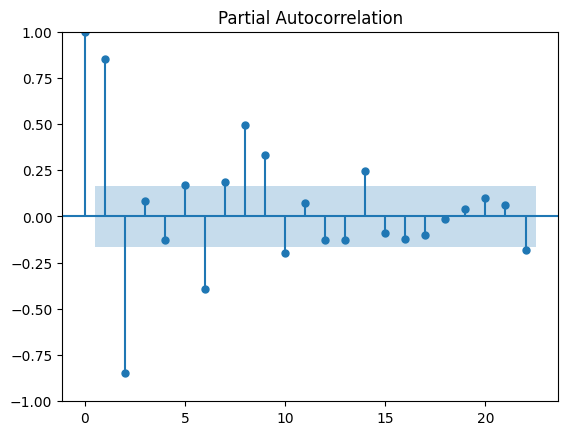

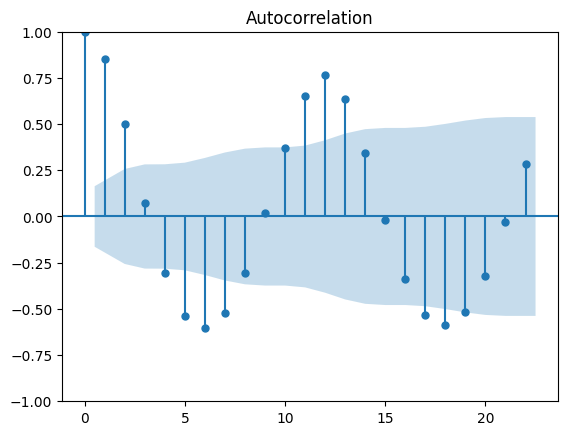

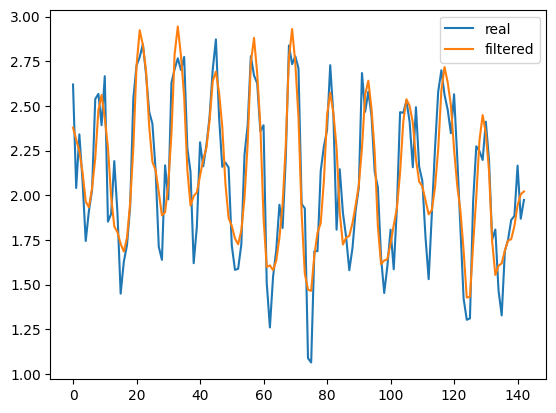

Serie: windspeedrecife.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


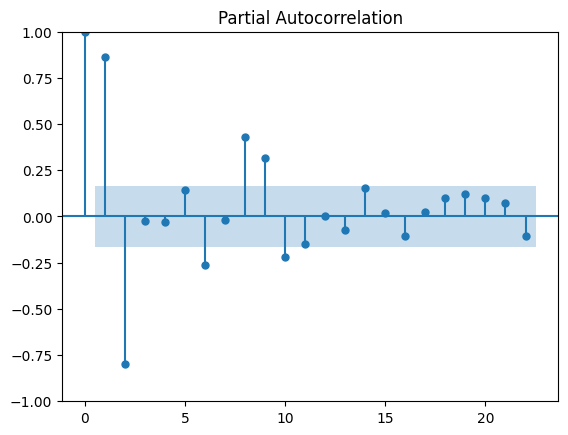

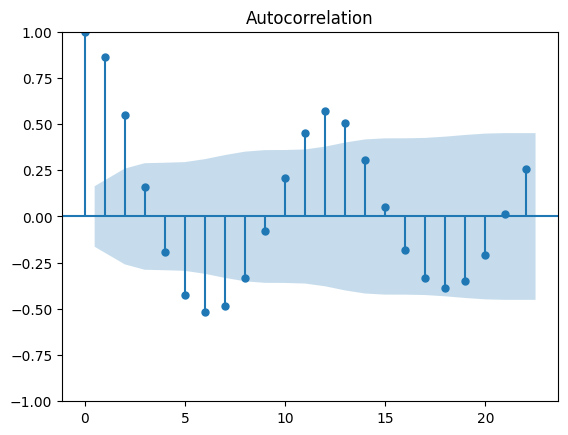

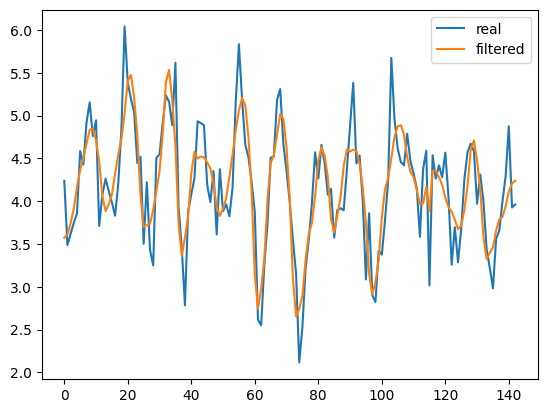

Serie: windspeednatal.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


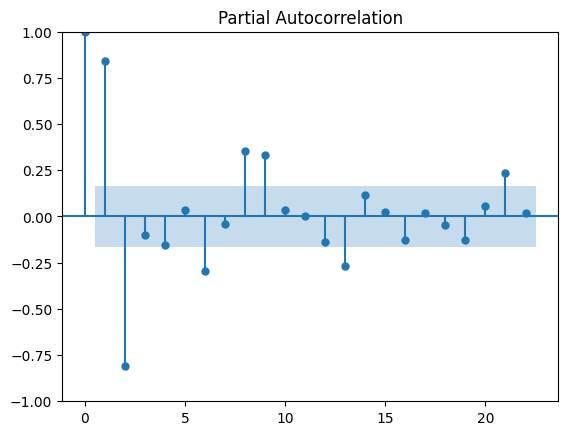

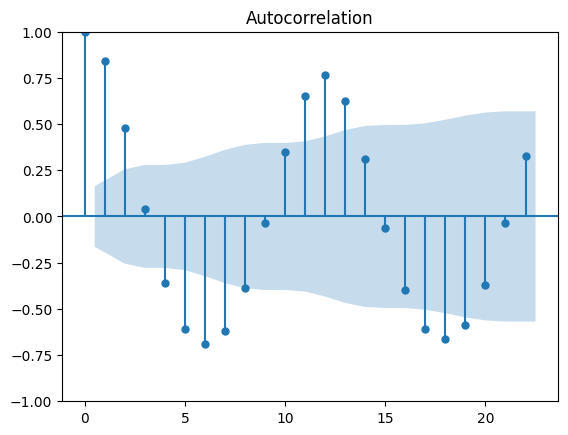

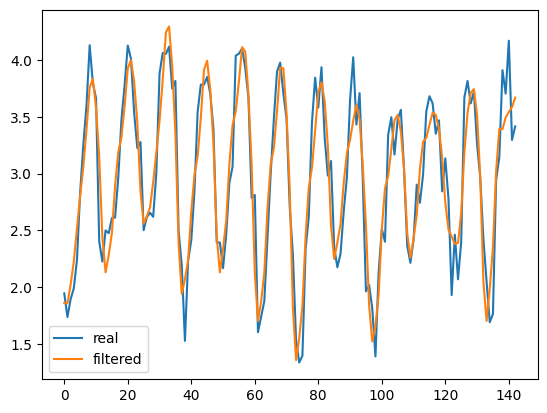

Serie: windspeedfortaleza.txt is_stationary False lags: 12 linhas: 104
****************************************************************************************************


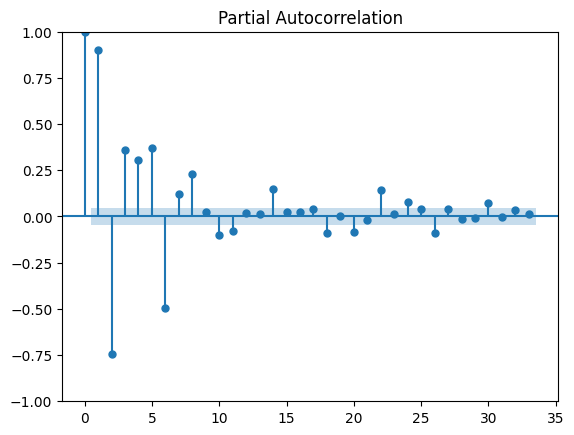

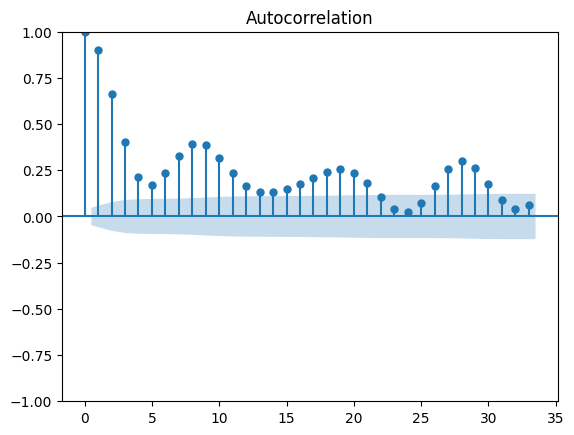

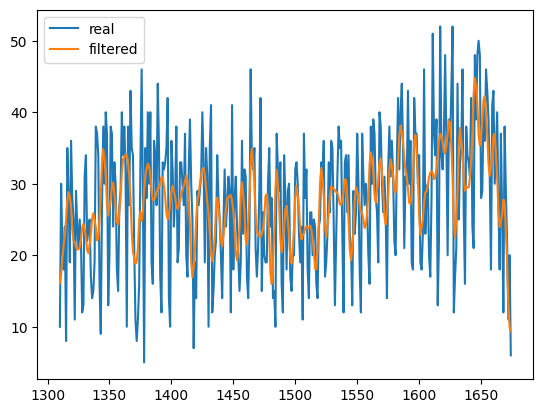

Serie: recifeaccday.txt is_stationary False lags: 7 linhas: 1334
****************************************************************************************************


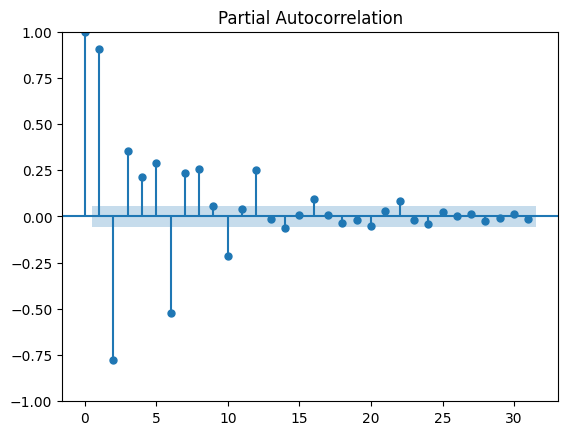

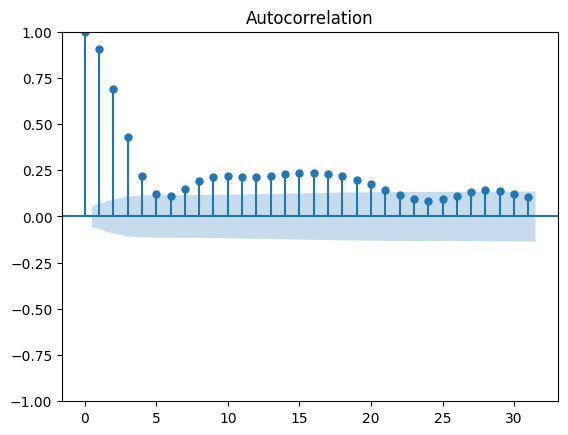

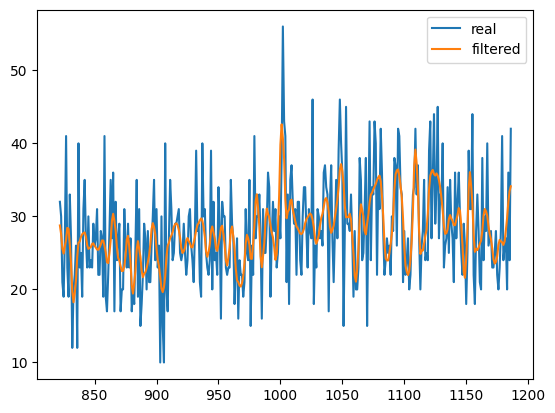

Serie: samurec.txt is_stationary False lags: 7 linhas: 945
****************************************************************************************************


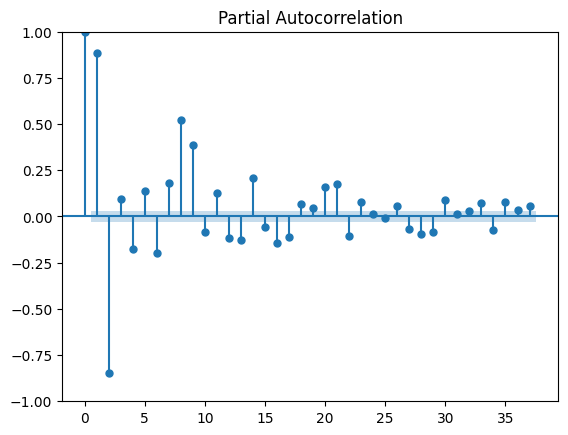

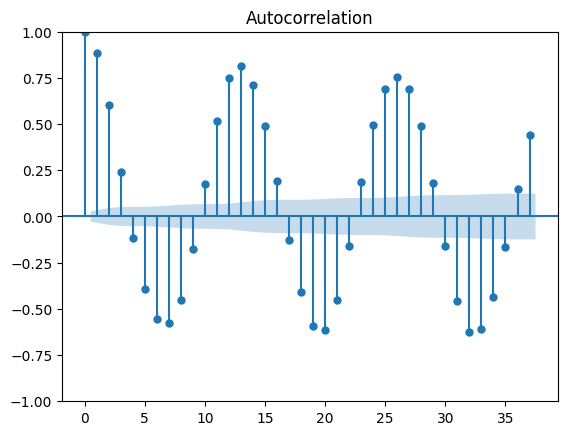

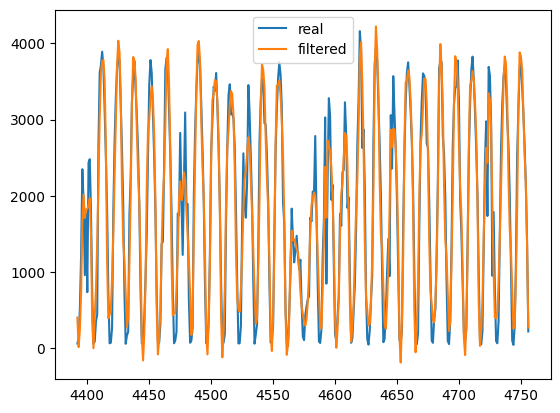

Serie: irradiancesalvador.txt is_stationary False lags: 17 linhas: 3791
****************************************************************************************************


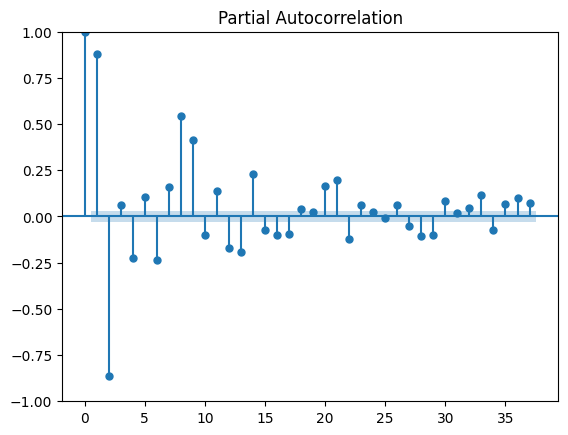

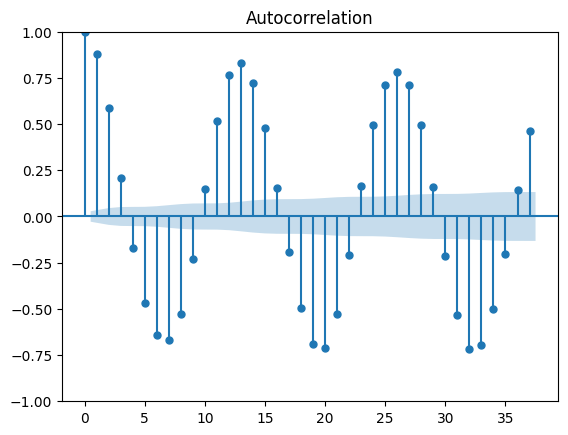

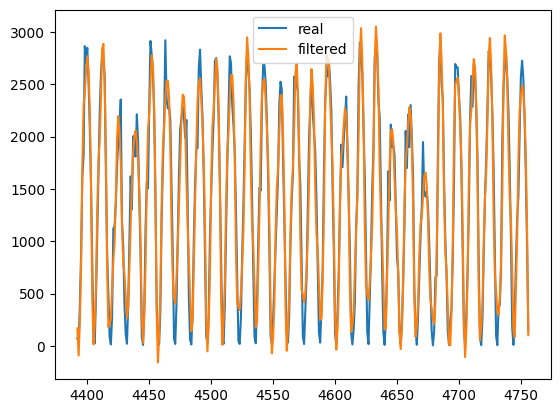

Serie: irradiancefortaleza.txt is_stationary False lags: 17 linhas: 3791
****************************************************************************************************


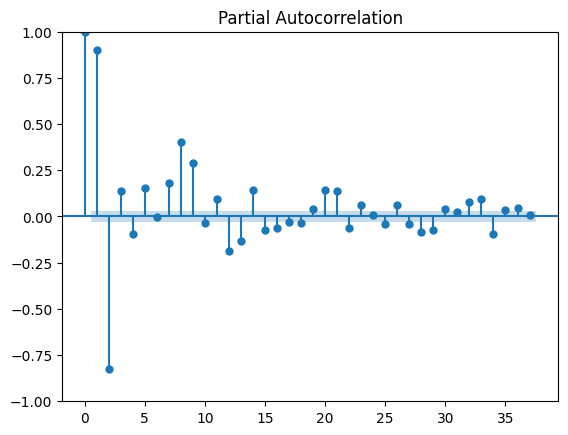

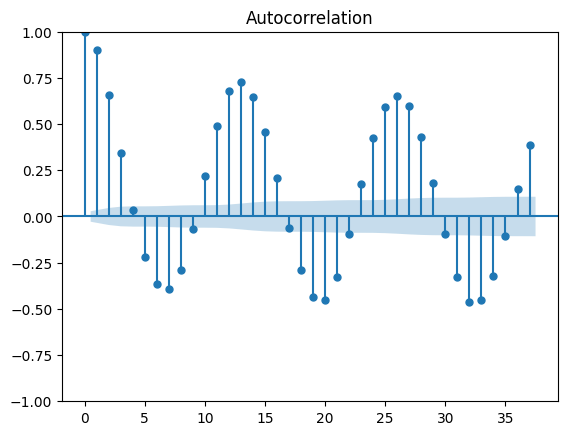

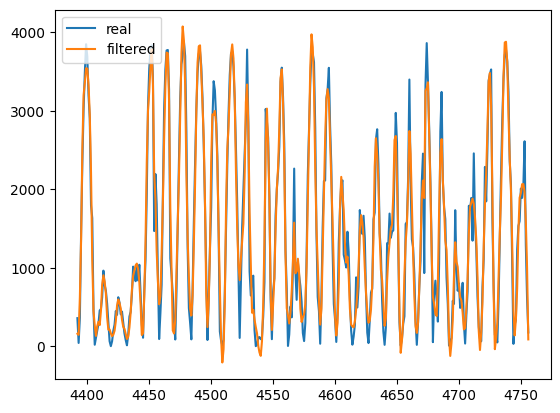

Serie: irradiancefloripa.txt is_stationary False lags: 15 linhas: 3793
****************************************************************************************************


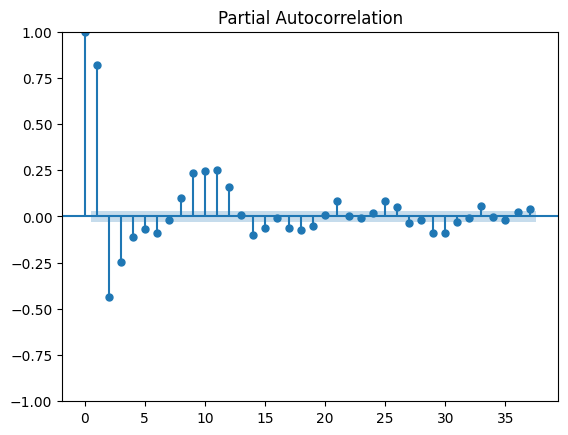

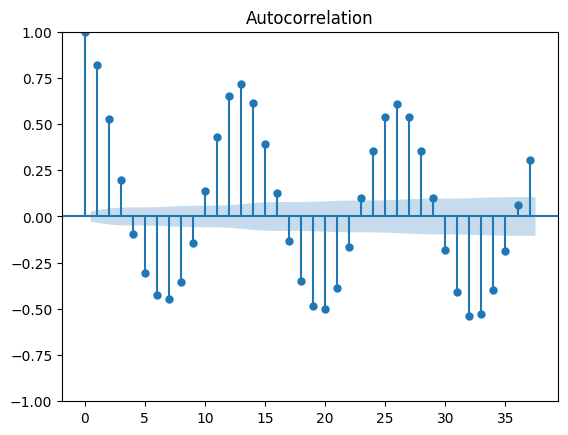

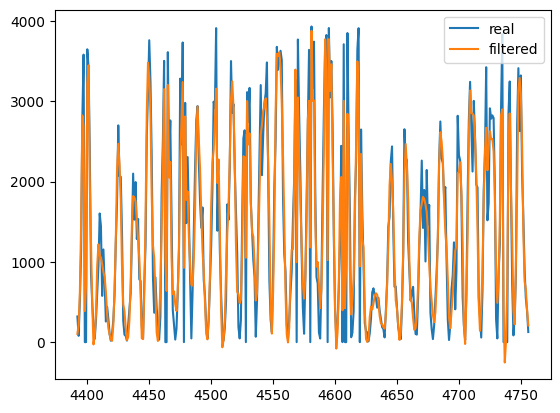

Serie: irradiancesp.txt is_stationary False lags: 17 linhas: 3791
****************************************************************************************************


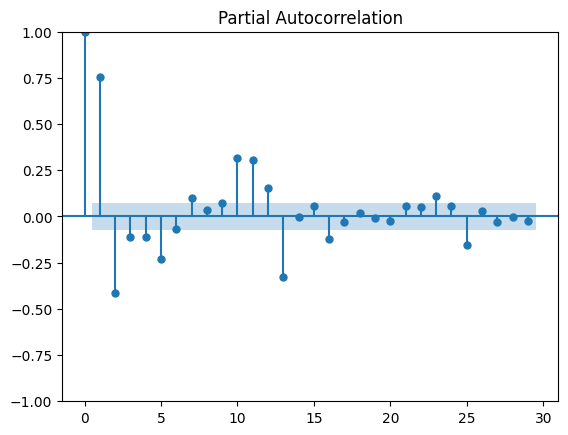

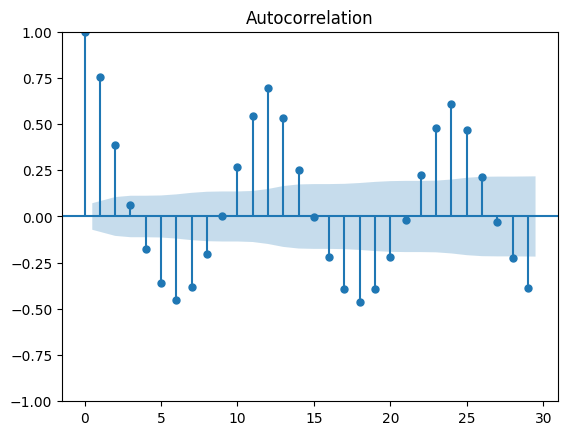

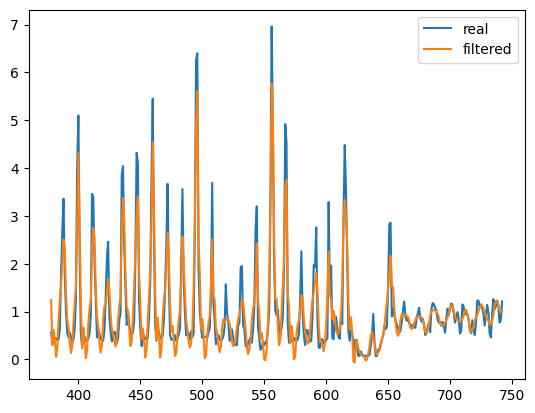

Serie: coloradoRiver.txt is_stationary False lags: 16 linhas: 580
****************************************************************************************************


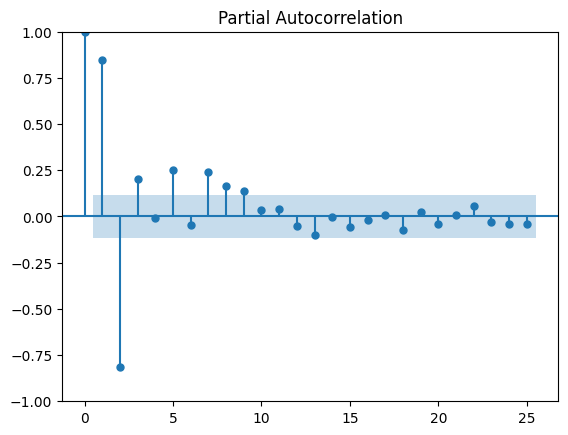

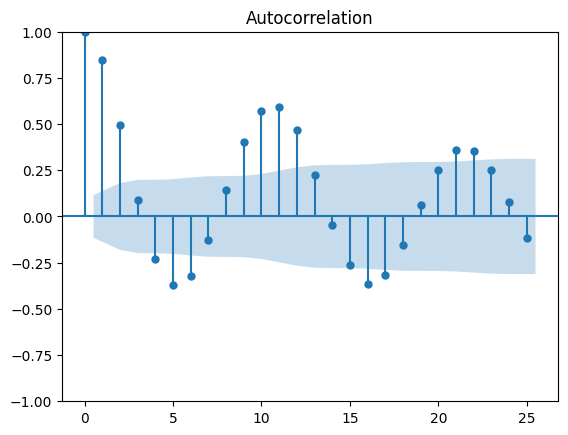

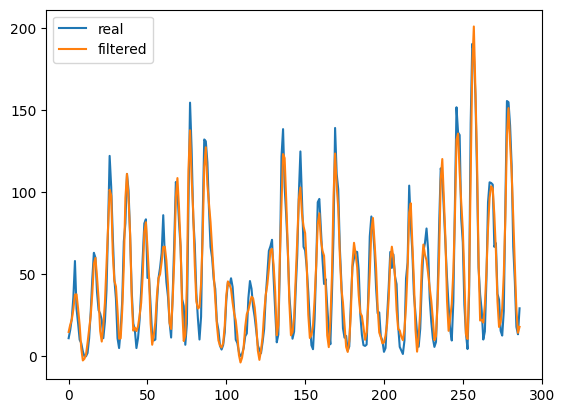

Serie: sunspot.txt is_stationary False lags: 9 linhas: 223
****************************************************************************************************


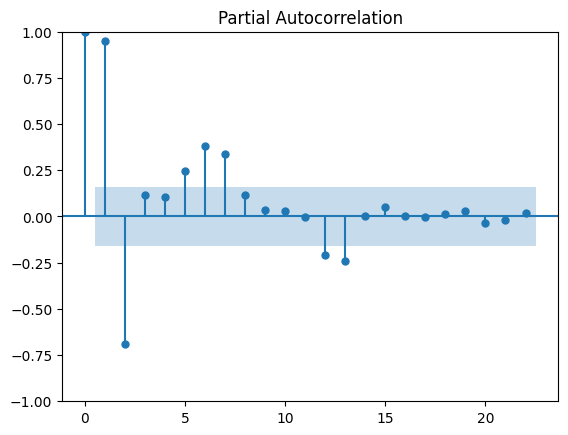

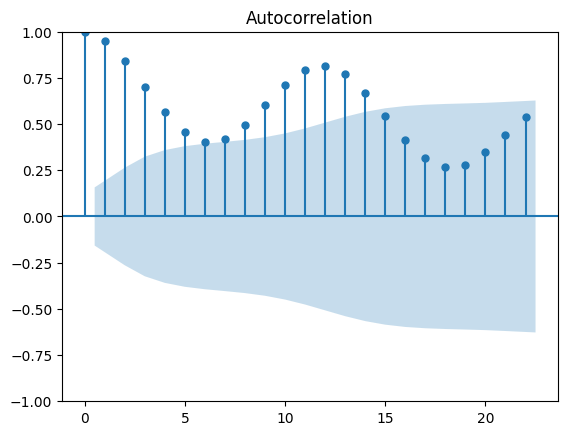

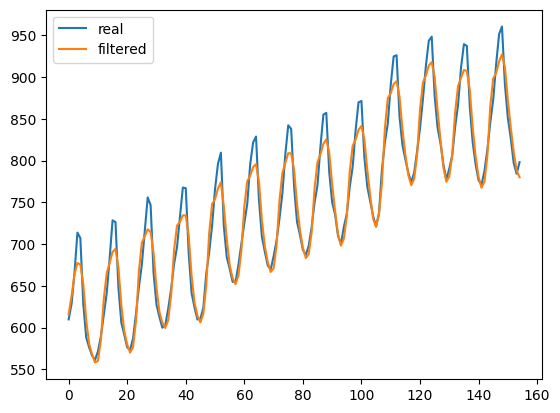

Serie: milk.txt is_stationary False lags: 20 linhas: 106
****************************************************************************************************


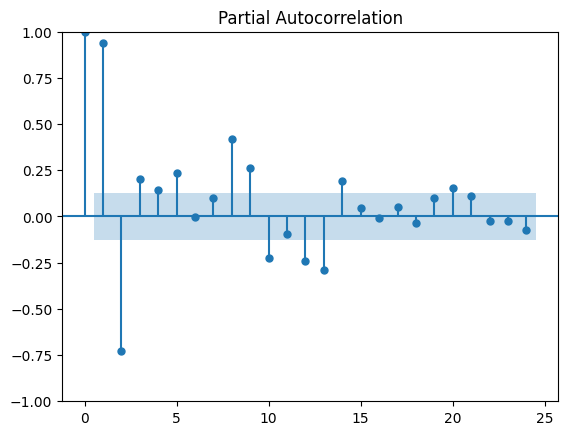

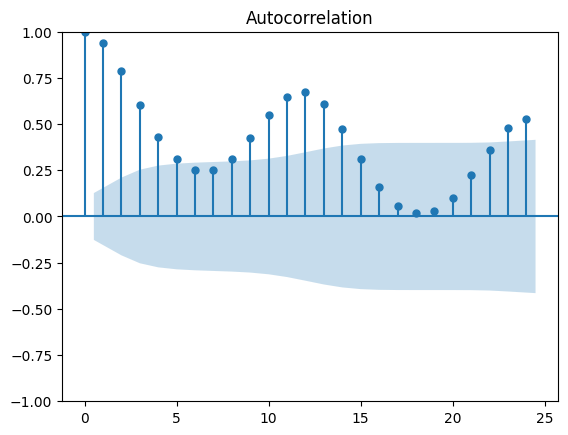

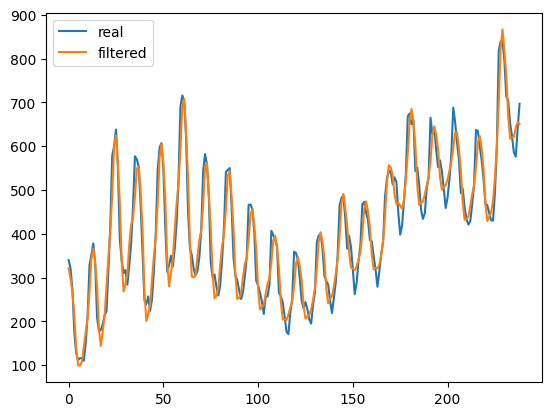

Serie: Unemployment.txt is_stationary False lags: 20 linhas: 172
****************************************************************************************************


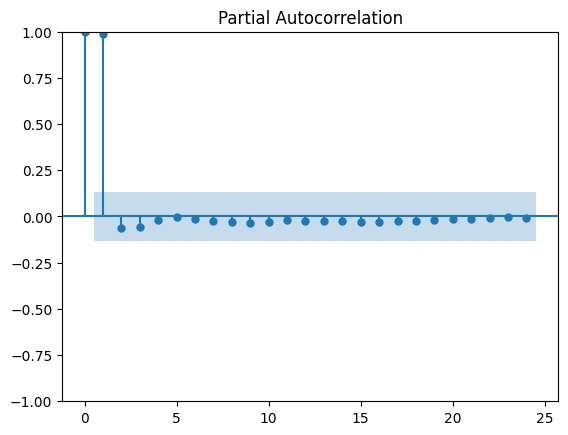

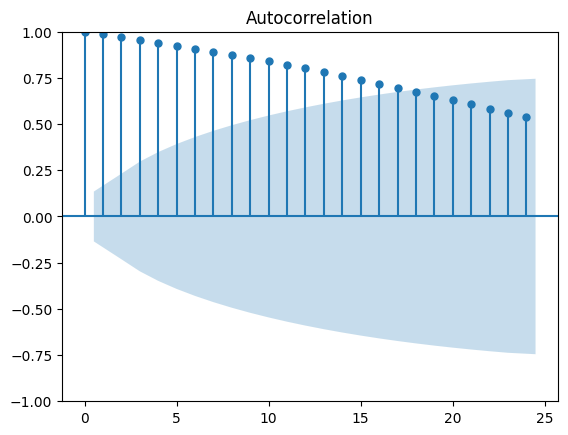

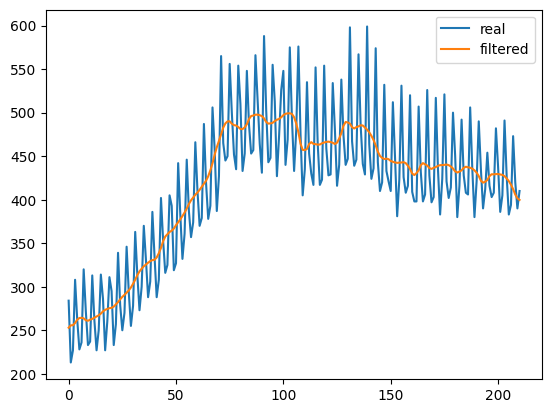

Serie: ausbee.txt is_stationary False lags: 20 linhas: 149
****************************************************************************************************


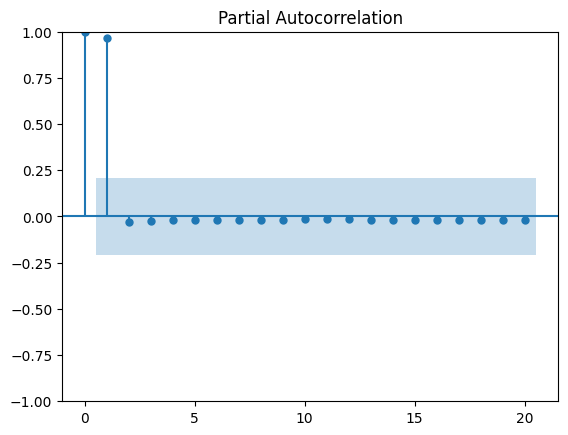

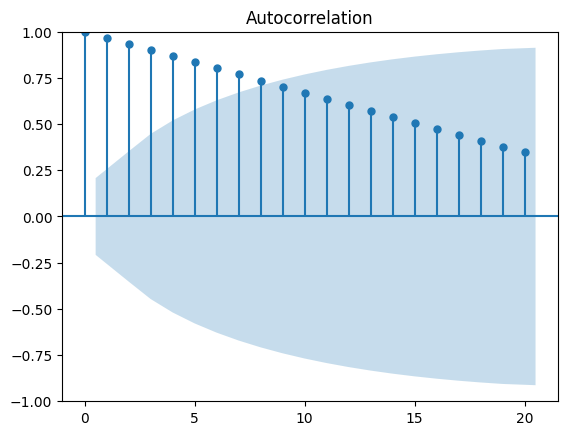

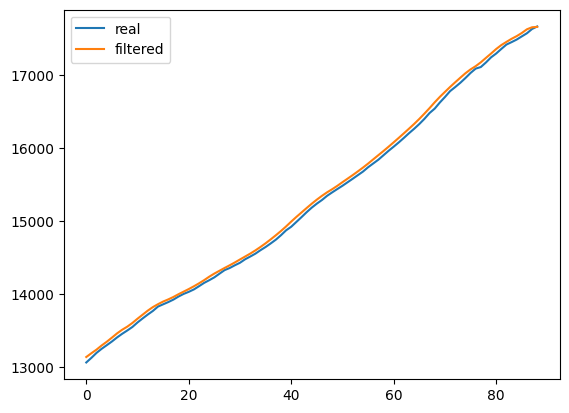

Serie: austres.txt is_stationary False lags: 1 linhas: 72
****************************************************************************************************


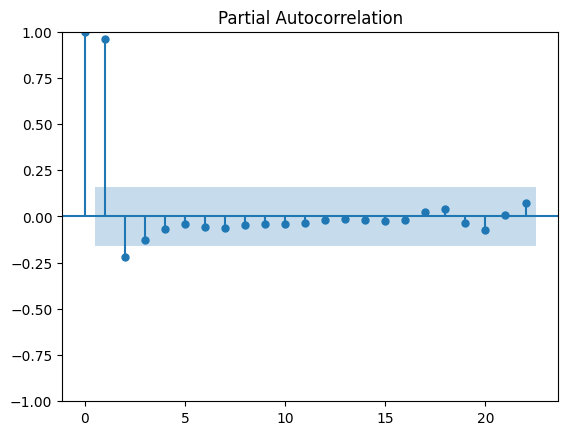

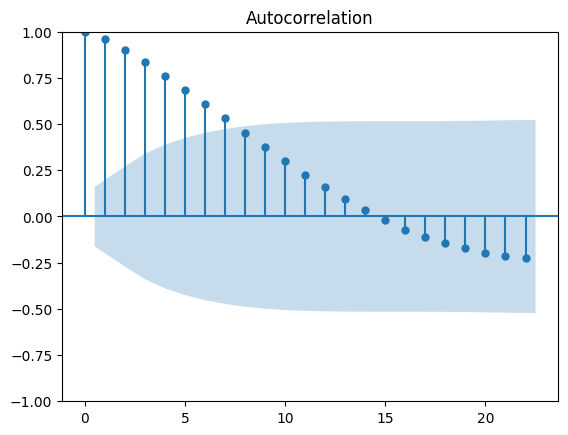

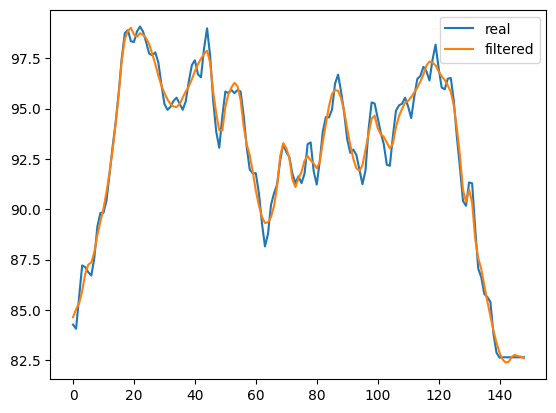

Serie: heartrate.txt is_stationary False lags: 2 linhas: 118
****************************************************************************************************


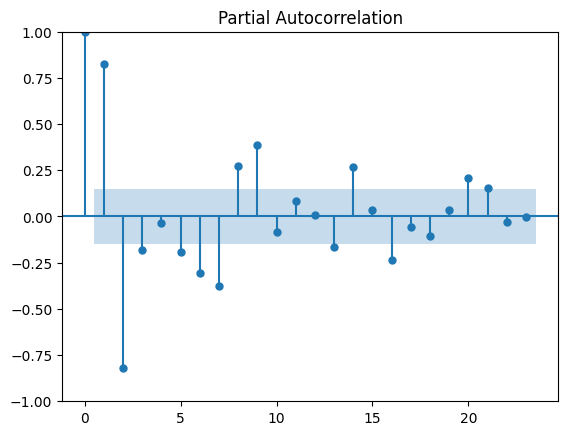

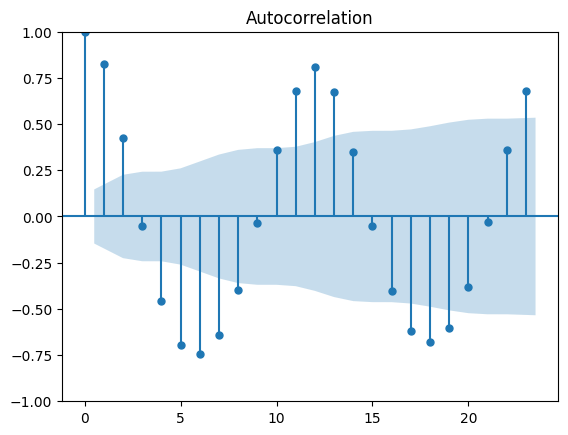

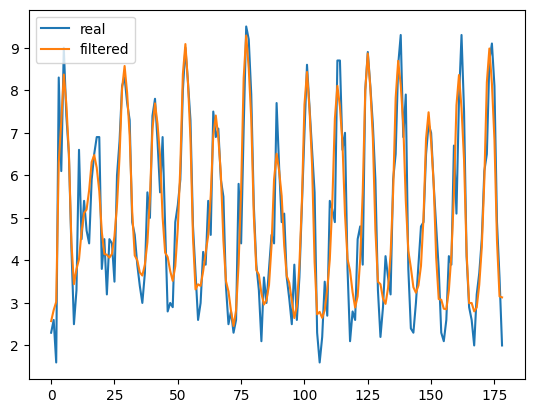

Serie: ozon.txt is_stationary False lags: 12 linhas: 132
****************************************************************************************************


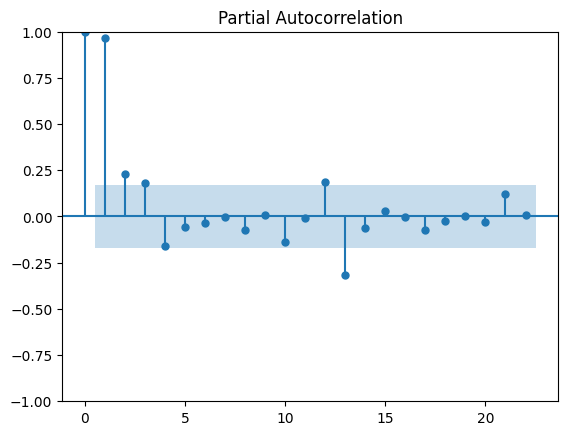

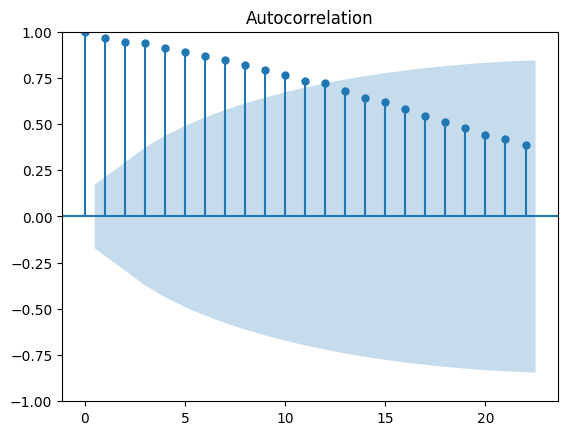

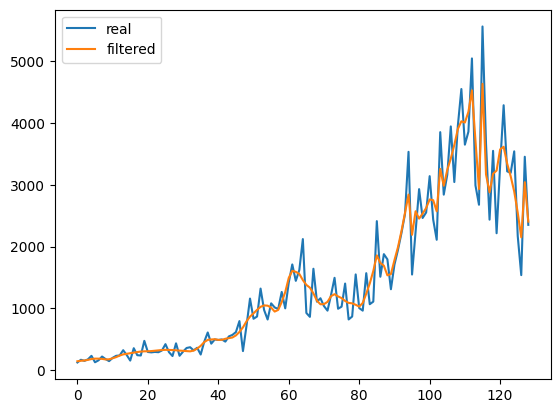

Serie: pollution.txt is_stationary False lags: 13 linhas: 91
****************************************************************************************************


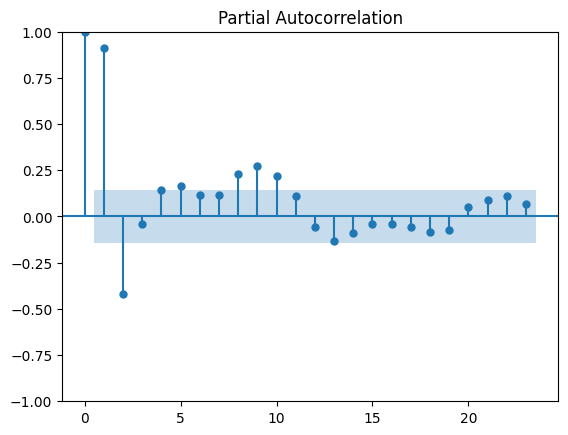

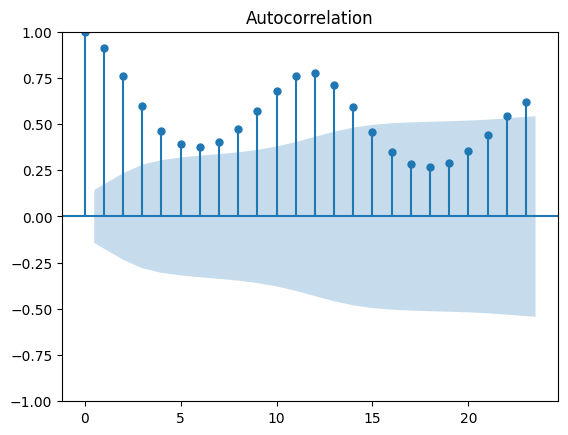

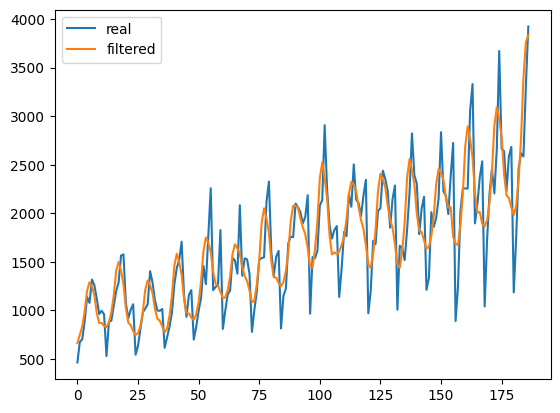

Serie: redwine.txt is_stationary False lags: 16 linhas: 135
****************************************************************************************************


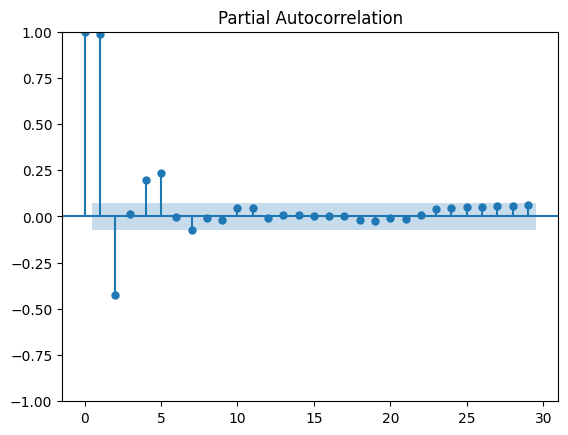

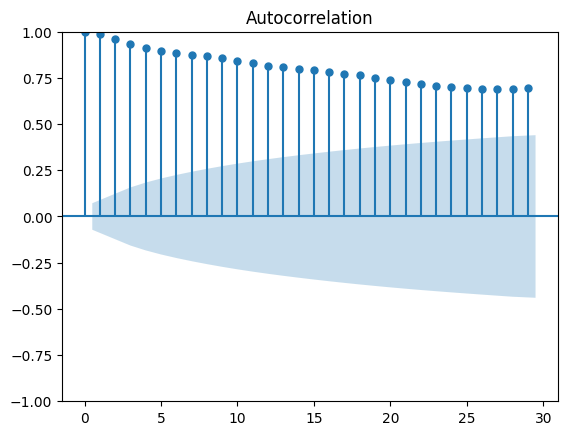

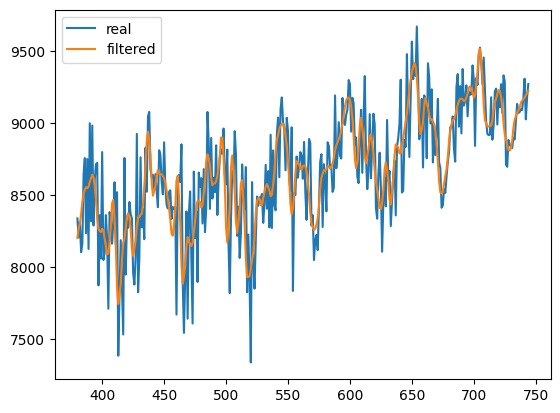

Serie: gasoline.txt is_stationary False lags: 8 linhas: 589
****************************************************************************************************


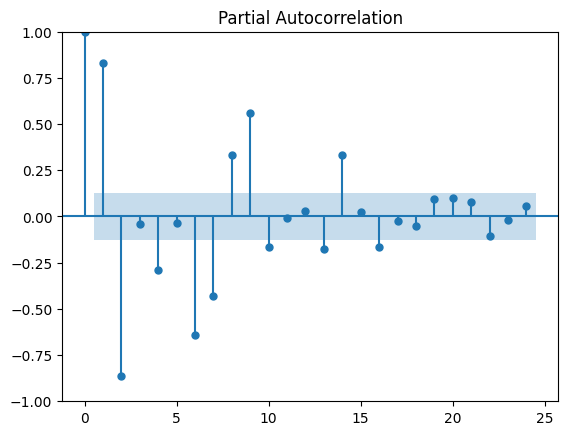

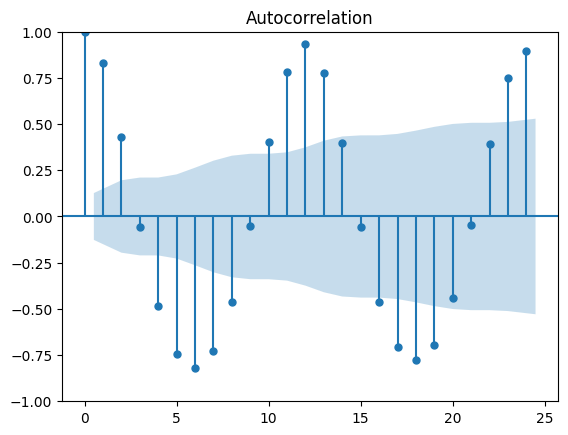

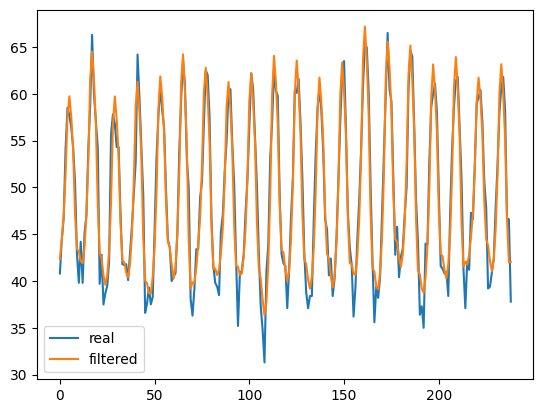

Serie: temperature.txt is_stationary False lags: 20 linhas: 172
****************************************************************************************************


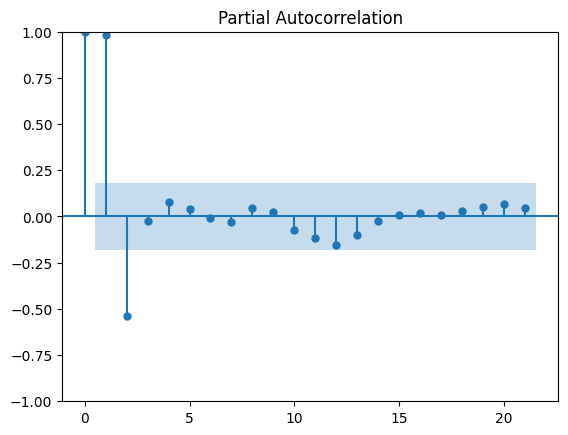

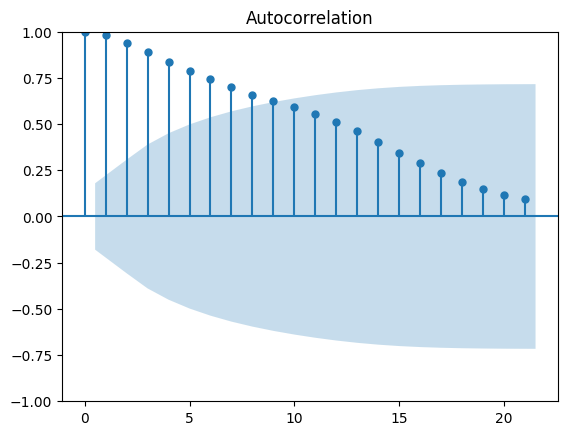

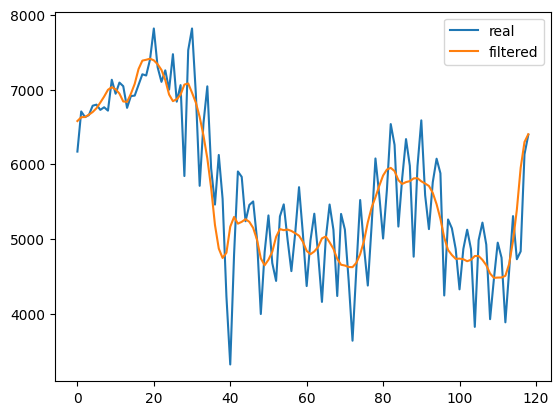

Serie: woolyrnq.txt is_stationary False lags: 17 linhas: 80
****************************************************************************************************


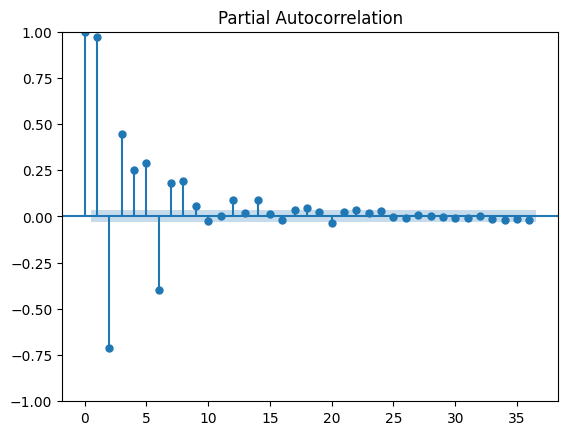

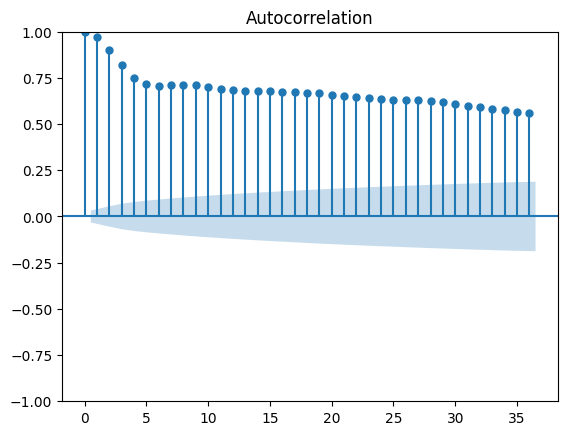

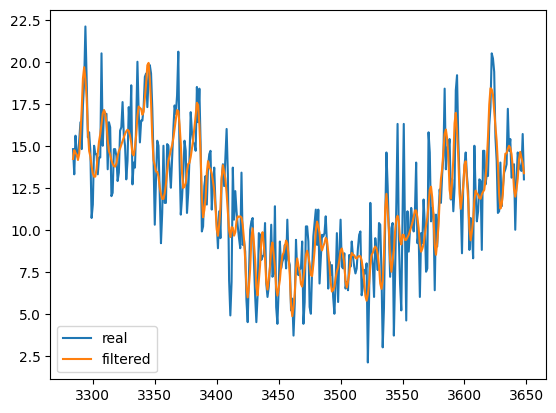

Serie: melbmin.txt is_stationary False lags: 20 linhas: 2900
****************************************************************************************************


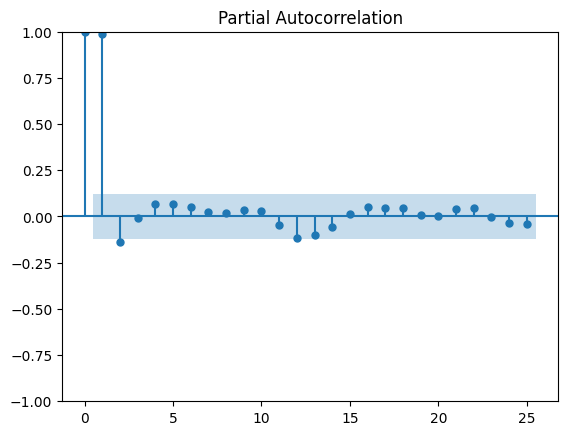

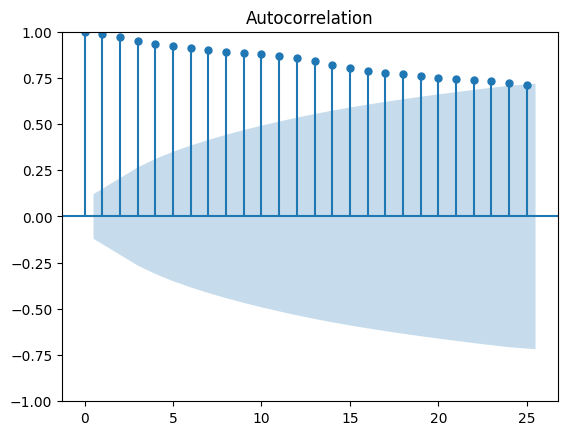

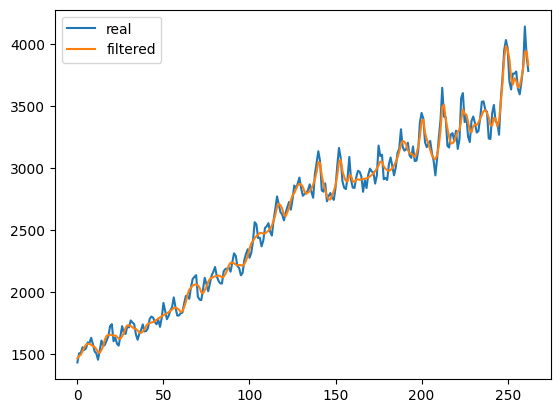

Serie: consumocoformated.txt is_stationary False lags: 12 linhas: 200
****************************************************************************************************


In [1]:
from input import input
import config
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

%load_ext autoreload
%autoreload 2
    
normalize = False
diff_kpss = False
lag_size = 'auto'
exec_config = {
    "test_size": config.TEST_SIZE,
    "val_size": config.VAL_SIZE,
    'horizon': 1,
    'normalize': normalize,
    'diff_kpss': diff_kpss,
    'type_filter': 'db4'
}

for base_name in config.BASE_NAME_LIST:
    exec_config['lag_size'] = config.BASE_INFORMATION[base_name]['lag_size']
    (
        ts_univariate,
        df_train, 
        df_val,
        df_test, 
        min_max_scaler,
        test_size, 
        val_size,
        is_stationary, 
        original_ts,
        lag_size_formated
        
    ) = input.open_format_train_val_test(base_name, exec_config).sequential_return()
    
    plot_pacf(ts_univariate)
    plt.show()
    plot_acf(ts_univariate)
    plt.show()
    pd.DataFrame(
        {'real': original_ts[-ts_univariate.shape[0]:],
        'filtered': ts_univariate}
    ).iloc[-365:].plot()
    plt.show()
    #result = seasonal_decompose(original_ts, model='additive', period=12)
    #fig = result.plot()
    #fig.set_size_inches(10, 8)
    #plt.tight_layout()
    #plt.show()
    print(f"Serie: {base_name} is_stationary {is_stationary} lags: {df_train.shape[1] -1} linhas: {df_train.shape[0]}")
    print('*' * 100)
    

In [9]:
t =pd.Series([2000, 2000, 2000 ])
c = pd.Series([-200, -300, -600])
(t + c).mean()

1633.3333333333333

In [10]:
2000 + c.mean()

1633.3333333333333